 # EmoLearn: Final Improvements
 ## Statistical Features, MIL, Gender Analysis, Leave-One-User-Out CV
 1. Statistical features (mean, std, min, max) across frames
 2. Attention-based MIL (Multiple Instance Learning)
 3. Feature distribution plots
 4. Gender-based performance evaluation
 5. Leave-One-User-Out cross-validation

 ## 1. Setup & Load Cached Features

In [ ]:
import os, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

if torch.backends.mps.is_available():
    device = torch.device("mps"); print("Using Apple M4 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda"); print("Using CUDA GPU")
else:
    device = torch.device("cpu"); print("Using CPU")

DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
FEATURE_DIR = os.path.join(DAISEE_ROOT, "Features")
LABEL_DIR = os.path.join(DAISEE_ROOT, "Labels")
GENDER_DIR = os.path.join(DAISEE_ROOT, "GenderClips")

# Load cached sequence features
print("Loading cached features...")
train_app = np.load(os.path.join(FEATURE_DIR, "Train_appearance_seq.npy"))
train_geo = np.load(os.path.join(FEATURE_DIR, "Train_geometric_seq.npy"))
train_lbl = np.load(os.path.join(FEATURE_DIR, "Train_labels_seq.npy"))

val_app = np.load(os.path.join(FEATURE_DIR, "Validation_appearance_seq.npy"))
val_geo = np.load(os.path.join(FEATURE_DIR, "Validation_geometric_seq.npy"))
val_lbl = np.load(os.path.join(FEATURE_DIR, "Validation_labels_seq.npy"))

test_app = np.load(os.path.join(FEATURE_DIR, "Test_appearance_seq.npy"))
test_geo = np.load(os.path.join(FEATURE_DIR, "Test_geometric_seq.npy"))
test_lbl = np.load(os.path.join(FEATURE_DIR, "Test_labels_seq.npy"))

# Load labels CSVs (for clip IDs and gender matching)
train_labels_df = pd.read_csv(os.path.join(LABEL_DIR, "TrainLabels.csv"))
val_labels_df = pd.read_csv(os.path.join(LABEL_DIR, "ValidationLabels.csv"))
test_labels_df = pd.read_csv(os.path.join(LABEL_DIR, "TestLabels.csv"))
FRUS_COL = "Frustration " if "Frustration " in train_labels_df.columns else "Frustration"

# Load gender lists
female_clips = set(open(os.path.join(GENDER_DIR, "Females")).read().strip().split("\n"))
male_clips = set(open(os.path.join(GENDER_DIR, "Males")).read().strip().split("\n"))

print(f"Train: {train_app.shape}, Val: {val_app.shape}, Test: {test_app.shape}")
print(f"Female clips: {len(female_clips)}, Male clips: {len(male_clips)}")

RESNET_DIM = 512
GEOM_DIM = 6
NUM_EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

Using Apple M4 GPU (MPS)
Loading cached features...
Train: (4852, 10, 512), Val: (1429, 10, 512), Test: (1638, 10, 512)
Female clips: 2841, Male clips: 6229


 ## 2. Compute Statistical Features

 Instead of averaging 10 frames into 1 vector, compute:
 mean, std, min, max across frames → 4x the feature dimension

 This preserves information about variability over time.
 A student who fidgets (high std in head pose) vs one who sits still (low std).

In [ ]:
def compute_stat_features(seq_features):
    """
    Input: (N, T, D) — N videos, T frames, D features
    Output: (N, D*4) — mean, std, min, max across frames
    """
    feat_mean = np.mean(seq_features, axis=1)  # (N, D)
    feat_std = np.std(seq_features, axis=1)    # (N, D)
    feat_min = np.min(seq_features, axis=1)    # (N, D)
    feat_max = np.max(seq_features, axis=1)    # (N, D)
    return np.concatenate([feat_mean, feat_std, feat_min, feat_max], axis=1)  # (N, D*4)

# Compute for all splits
train_app_stat = compute_stat_features(train_app)  # (N, 2048)
train_geo_stat = compute_stat_features(train_geo)  # (N, 24)
val_app_stat = compute_stat_features(val_app)
val_geo_stat = compute_stat_features(val_geo)
test_app_stat = compute_stat_features(test_app)
test_geo_stat = compute_stat_features(test_geo)

print(f"Statistical features computed:")
print(f"  Appearance: {train_app.shape} → {train_app_stat.shape}  (mean/std/min/max × 512)")
print(f"  Geometric:  {train_geo.shape} → {train_geo_stat.shape}  (mean/std/min/max × 6)")

Statistical features computed:
  Appearance: (4852, 10, 512) → (4852, 2048)  (mean/std/min/max × 512)
  Geometric:  (4852, 10, 6) → (4852, 24)  (mean/std/min/max × 6)


 ## 3. Feature Distribution Plots

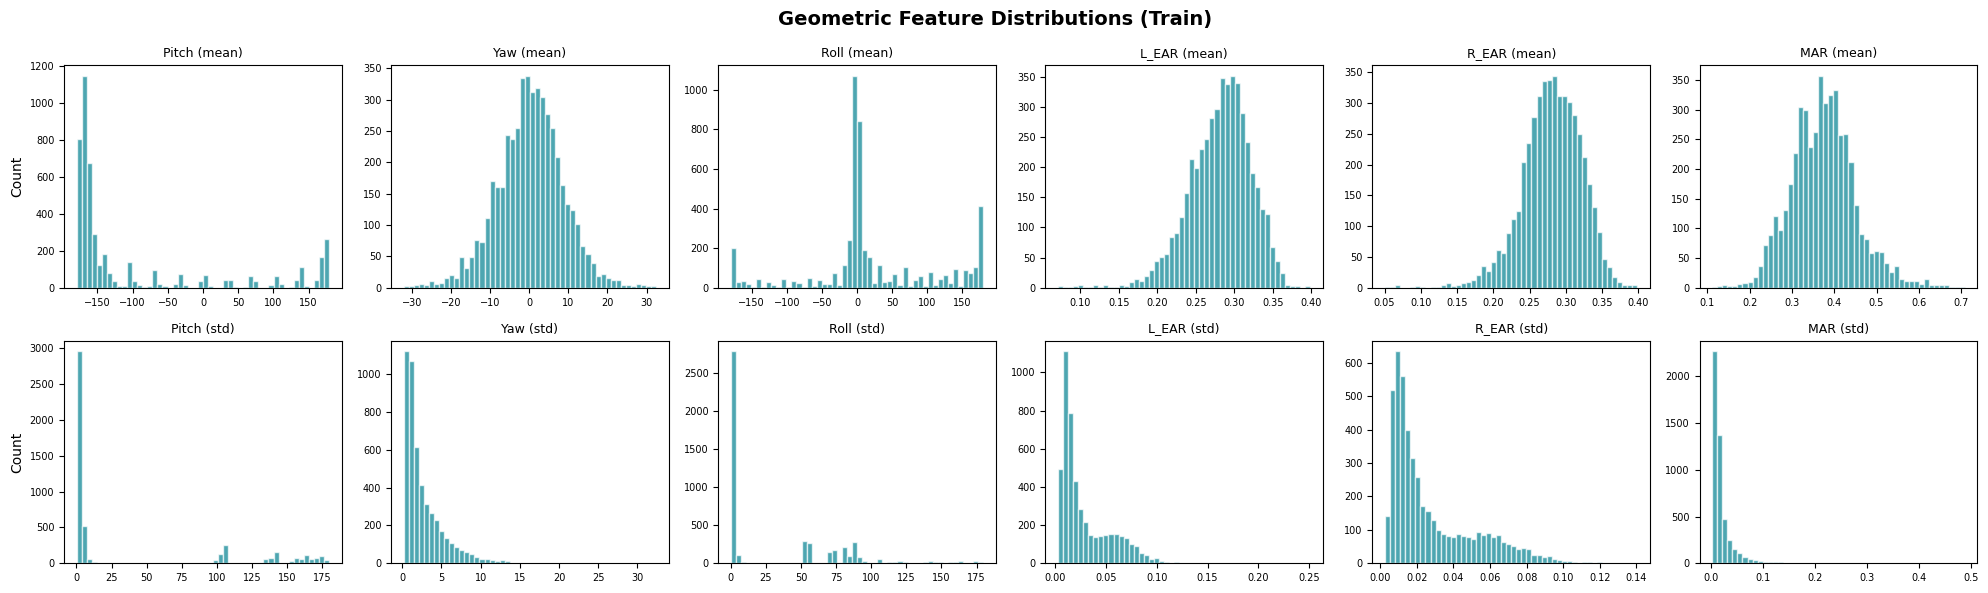

In [ ]:
# --- Geometric feature distributions ---
geo_names = ["Pitch (mean)", "Yaw (mean)", "Roll (mean)", "L_EAR (mean)", "R_EAR (mean)", "MAR (mean)",
             "Pitch (std)", "Yaw (std)", "Roll (std)", "L_EAR (std)", "R_EAR (std)", "MAR (std)"]

fig, axes = plt.subplots(2, 6, figsize=(20, 6))
fig.suptitle("Geometric Feature Distributions (Train)", fontsize=14, fontweight="bold")

for i in range(12):
    ax = axes[i // 6][i % 6]
    ax.hist(train_geo_stat[:, i], bins=50, color="#028090", alpha=0.7, edgecolor="white")
    ax.set_title(geo_names[i], fontsize=9)
    ax.set_ylabel("Count" if i % 6 == 0 else "")
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("geo_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

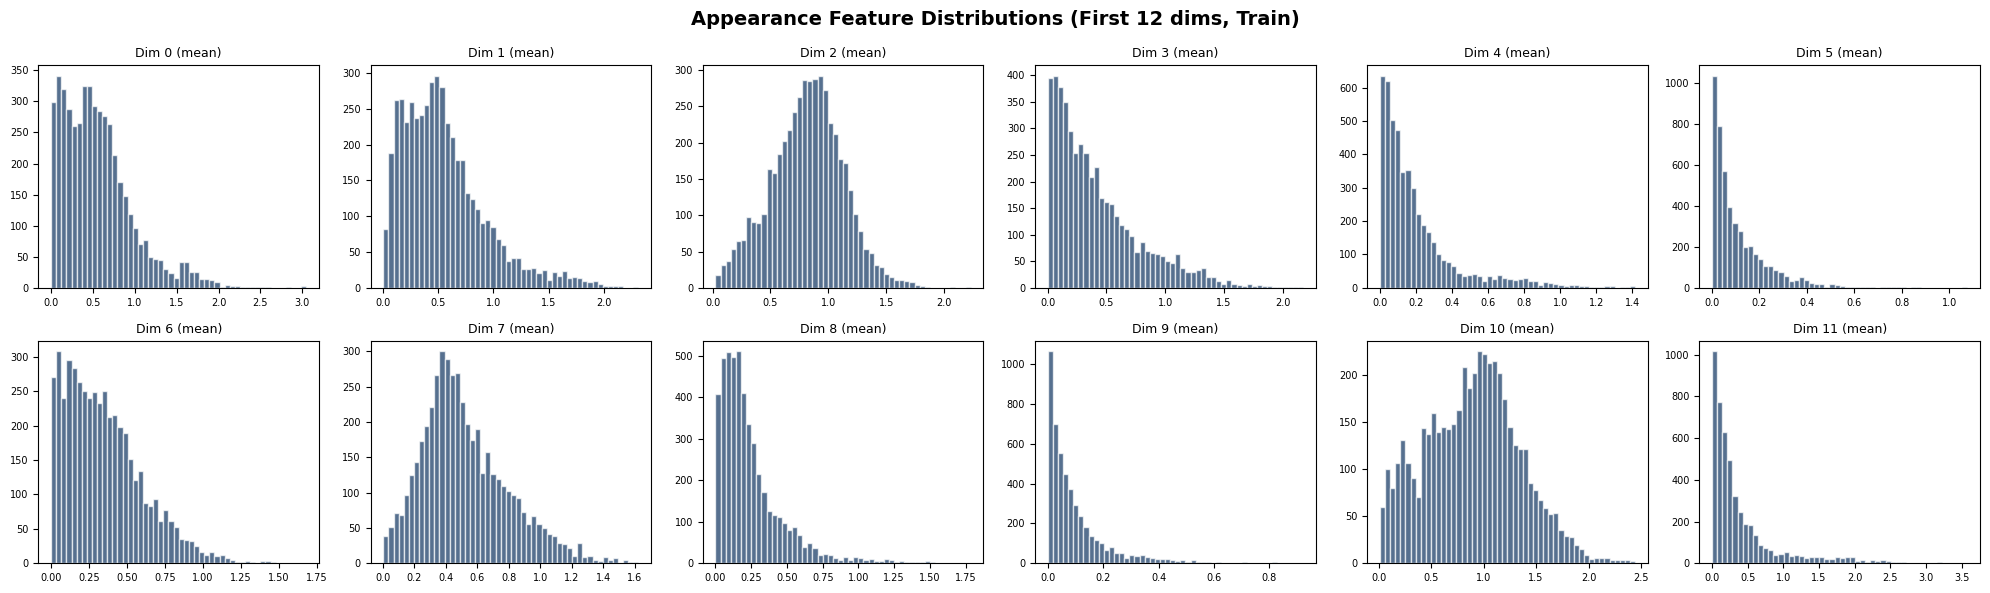

In [ ]:
# --- Appearance feature distributions (show first 12 dims as example) ---
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
fig.suptitle("Appearance Feature Distributions (First 12 dims, Train)", fontsize=14, fontweight="bold")

app_names_prefix = ["Mean", "Std", "Min", "Max"]
for i in range(12):
    ax = axes[i // 6][i % 6]
    dim_idx = i  # first 12 dimensions of mean
    ax.hist(train_app_stat[:, dim_idx], bins=50, color="#0F3460", alpha=0.7, edgecolor="white")
    ax.set_title(f"Dim {i} (mean)", fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("app_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

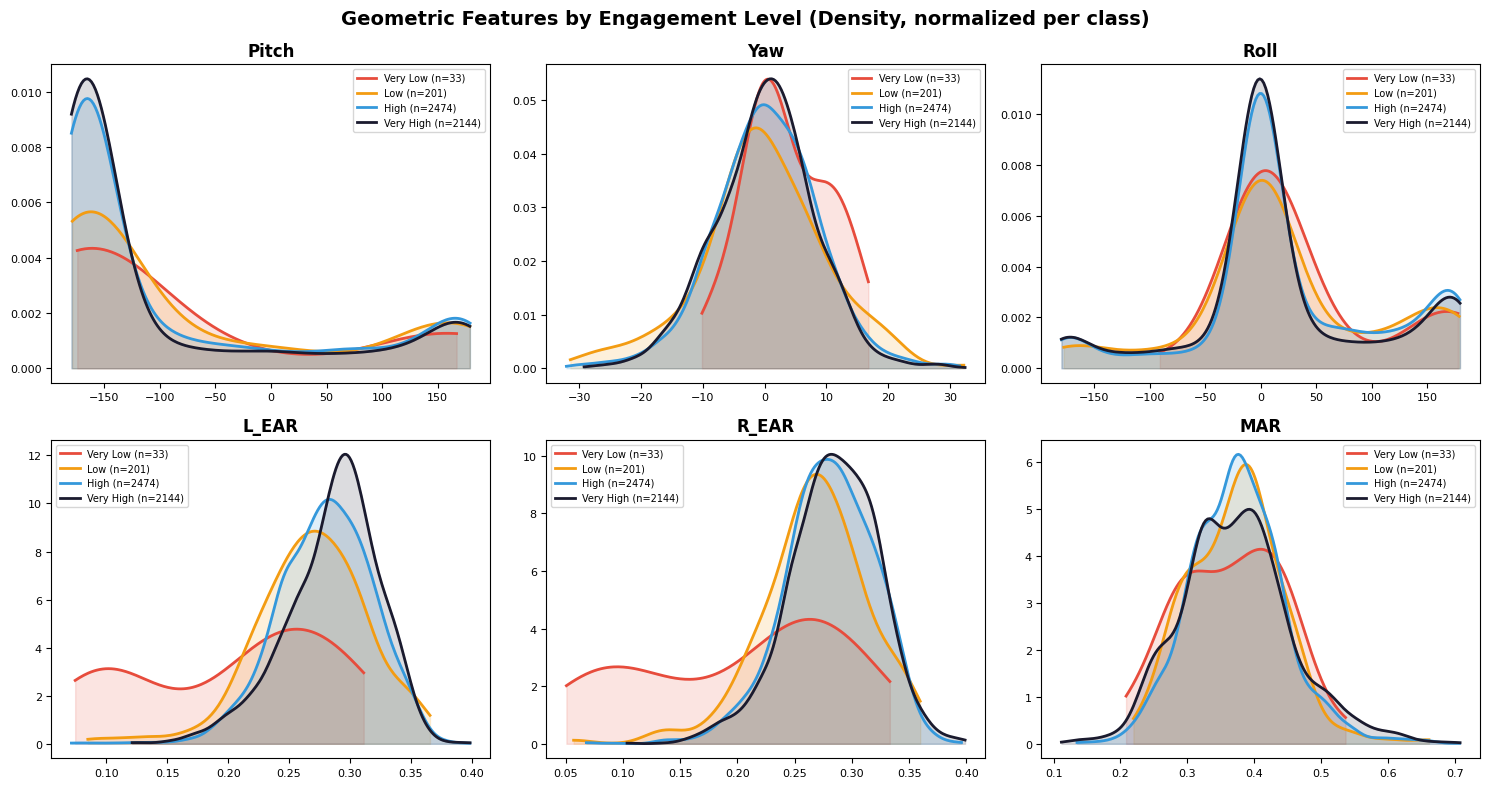

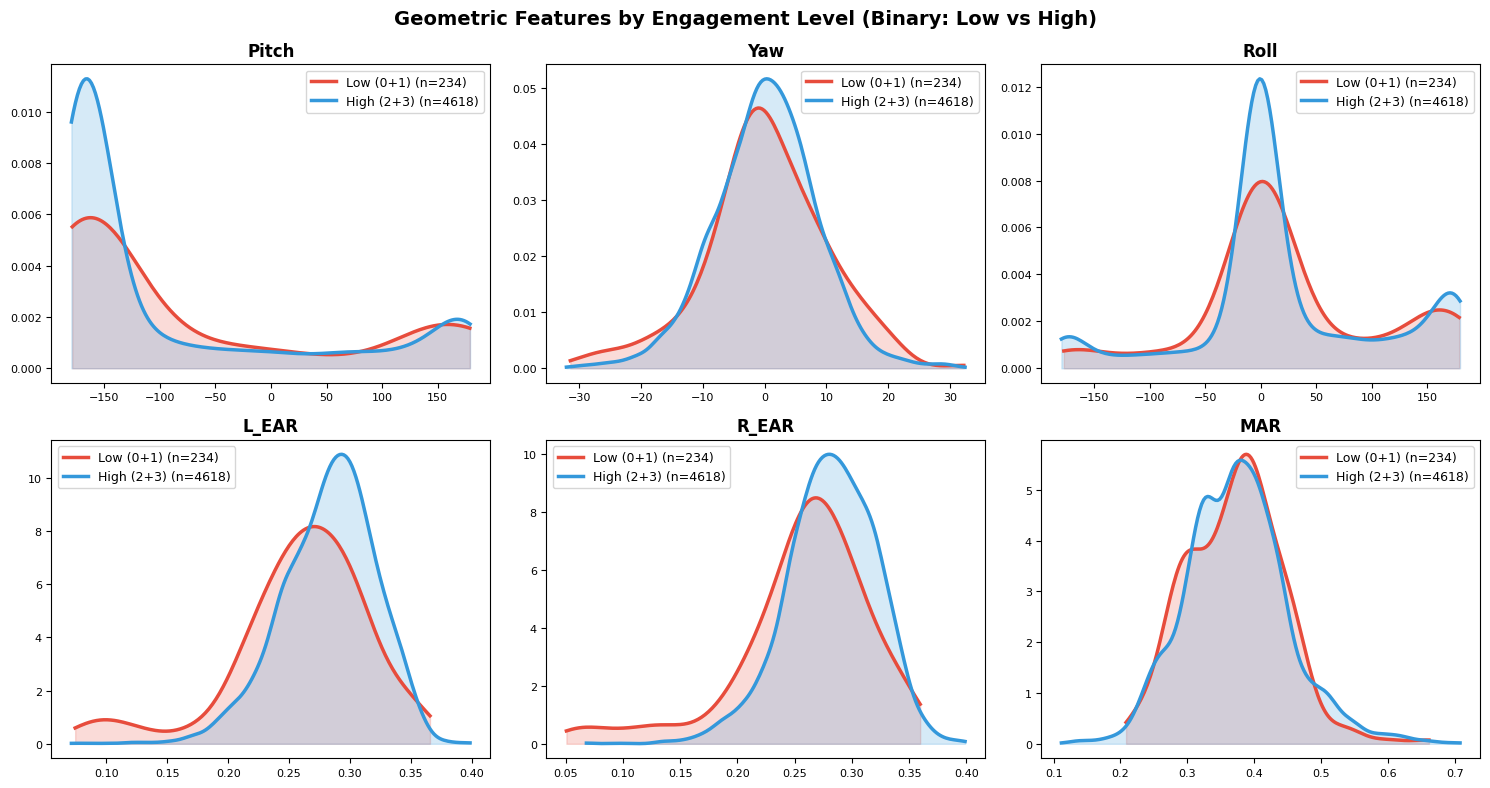

In [ ]:
# --- Geometric features by engagement level (NORMALIZED) ---
from scipy.stats import gaussian_kde

geo_short = ["Pitch", "Yaw", "Roll", "L_EAR", "R_EAR", "MAR"]
eng_labels = train_lbl[:, 1]
colors = ["#E74C3C", "#F39C12", "#3498DB", "#1A1A2E"]
level_names = ["Very Low", "Low", "High", "Very High"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Geometric Features by Engagement Level (Density, normalized per class)", fontsize=14, fontweight="bold")

for i, (ax, name) in enumerate(zip(axes.flat, geo_short)):
    for level in [0, 1, 2, 3]:
        mask = eng_labels == level
        data = train_geo_stat[mask, i]
        if len(data) > 5:
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 200)
                ax.plot(x_range, kde(x_range), color=colors[level], linewidth=2,
                        label=f"{level_names[level]} (n={mask.sum()})")
                ax.fill_between(x_range, kde(x_range), alpha=0.15, color=colors[level])
            except:
                pass
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("geo_by_engagement_4class.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Binary version ---
binary_labels = (eng_labels >= 2).astype(int)
binary_names = ["Low (0+1)", "High (2+3)"]
binary_colors = ["#E74C3C", "#3498DB"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Geometric Features by Engagement Level (Binary: Low vs High)", fontsize=14, fontweight="bold")

for i, (ax, name) in enumerate(zip(axes.flat, geo_short)):
    for level in [0, 1]:
        mask = binary_labels == level
        data = train_geo_stat[mask, i]
        if len(data) > 5:
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 200)
                ax.plot(x_range, kde(x_range), color=binary_colors[level], linewidth=2.5,
                        label=f"{binary_names[level]} (n={mask.sum()})")
                ax.fill_between(x_range, kde(x_range), alpha=0.2, color=binary_colors[level])
            except:
                pass
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("geo_by_engagement_binary.png", dpi=150, bbox_inches="tight")
plt.show()

 ## 4. Datasets & Training Utilities

In [ ]:
TARGET_COL = 1  # Engagement

class StatDataset(Dataset):
    """Dataset using statistical features (mean/std/min/max)."""
    def __init__(self, app_stat, geo_stat, labels, target_col=1, binary=True):
        self.app = torch.tensor(app_stat, dtype=torch.float32)
        self.geo = torch.tensor(geo_stat, dtype=torch.float32)
        raw = labels[:, target_col]
        self.labels = torch.tensor((raw >= 2).astype(np.int64) if binary else raw, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.app[idx], self.geo[idx], self.labels[idx]

class SeqDataset(Dataset):
    """Dataset using raw frame sequences."""
    def __init__(self, app_seq, geo_seq, labels, target_col=1, binary=True):
        self.app = torch.tensor(app_seq, dtype=torch.float32)
        self.geo = torch.tensor(geo_seq, dtype=torch.float32)
        raw = labels[:, target_col]
        self.labels = torch.tensor((raw >= 2).astype(np.int64) if binary else raw, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.app[idx], self.geo[idx], self.labels[idx]

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha if isinstance(alpha, torch.Tensor) else (torch.tensor(alpha) if alpha is not None else None)
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        w = (1 - pt) ** self.gamma
        if self.alpha is not None:
            w = self.alpha.to(inputs.device)[targets] * w
        return (w * ce).mean()

def make_loader(dataset, oversample=False):
    if oversample:
        labels = dataset.labels.numpy()
        counts = Counter(labels)
        w = {c: len(labels) / n for c, n in counts.items()}
        sampler = WeightedRandomSampler([w[int(l)] for l in labels], len(labels), replacement=True)
        return DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

def get_class_weights(dataset):
    counts = Counter(dataset.labels.numpy())
    tot = sum(counts.values())
    nc = len(counts)
    return torch.tensor([tot / (nc * counts[c]) for c in sorted(counts.keys())], dtype=torch.float32)

def train_model(model, train_loader, val_loader, criterion=None, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    model = model.to(device)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if hasattr(criterion, 'weight') and criterion.weight is not None:
        criterion.weight = criterion.weight.to(device)
    if hasattr(criterion, 'alpha') and criterion.alpha is not None:
        criterion.alpha = criterion.alpha.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_f1, best_state = 0, None
    for epoch in range(num_epochs):
        model.train()
        for a, g, l in train_loader:
            a, g, l = a.to(device), g.to(device), l.to(device)
            optimizer.zero_grad()
            out = model(a, g)
            criterion(out, l).backward()
            optimizer.step()
        model.eval()
        vp, vl_list = [], []
        with torch.no_grad():
            for a, g, l in val_loader:
                a, g = a.to(device), g.to(device)
                vp.extend(model(a, g).argmax(1).cpu().numpy())
                vl_list.extend(l.numpy())
        vf1 = f1_score(vl_list, vp, average="macro", zero_division=0)
        va = accuracy_score(vl_list, vp)
        scheduler.step(1 - vf1)
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs}: Val Acc {va:.4f} | Val F1 {vf1:.4f}")
    if best_state:
        model.load_state_dict(best_state)
        model.to(device)
    print(f"  Best val F1: {best_f1:.4f}")
    return model

def evaluate_model(model, loader, binary=True):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for a, g, l in loader:
            a, g = a.to(device), g.to(device)
            preds.extend(model(a, g).argmax(1).cpu().numpy())
            labels.extend(l.numpy())
    p, l = np.array(preds), np.array(labels)
    tn = ["Low", "High"] if binary else ["VeryLow", "Low", "High", "VeryHigh"]
    return {
        "accuracy": accuracy_score(l, p),
        "f1_macro": f1_score(l, p, average="macro", zero_division=0),
        "predictions": p, "labels": l,
        "report": classification_report(l, p, target_names=tn, zero_division=0)
    }

 ## 5. Model Definitions

In [ ]:
# --- Statistical Feature Models (new) ---

class StatMLP(nn.Module):
    """MLP on statistical features (mean/std/min/max)."""
    def __init__(self, app_dim=RESNET_DIM*4, geo_dim=GEOM_DIM*4, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(app_dim + geo_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    def forward(self, app, geo):
        return self.net(torch.cat([app, geo], dim=1))

class StatAppMLP(nn.Module):
    """MLP on appearance statistical features only."""
    def __init__(self, app_dim=RESNET_DIM*4, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(app_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    def forward(self, app, geo):
        return self.net(app)

# --- Sequence Models (same as before) ---

class AttentionGRU(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.agru = nn.GRU(RESNET_DIM, 64, batch_first=True)
        self.ggru = nn.GRU(GEOM_DIM, 32, batch_first=True)
        self.attn_a = nn.Linear(64, 32); self.attn_g = nn.Linear(32, 32); self.attn_s = nn.Linear(32, 1)
        self.cls = nn.Sequential(nn.Dropout(0.3), nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, app, geo):
        _, ah = self.agru(app); _, gh = self.ggru(geo)
        ar, gr = ah[-1], gh[-1]
        st = torch.stack([torch.tanh(self.attn_a(ar)), torch.tanh(self.attn_g(gr))], 1)
        w = torch.softmax(self.attn_s(st).squeeze(-1), 1)
        return self.cls(torch.cat([ar * w[:, 0:1], gr * w[:, 1:2]], 1))

# --- MIL (Multiple Instance Learning) ---

class AttentionMIL(nn.Module):
    """
    Attention-based Multiple Instance Learning.
    Treats each video as a 'bag' of 10 frame 'instances'.
    Learns which frames are most important for classification.
    
    Unlike GRU which processes sequentially, MIL uses attention pooling
    to weight each frame independently.
    """
    def __init__(self, app_dim=RESNET_DIM, geo_dim=GEOM_DIM, hidden=128, num_classes=2):
        super().__init__()
        input_dim = app_dim + geo_dim  # 518 per frame
        
        # Instance-level feature transform
        self.instance_transform = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(0.2))
        
        # Attention mechanism (Ilse et al., 2018)
        self.attention = nn.Sequential(
            nn.Linear(hidden, 64), nn.Tanh(),
            nn.Linear(64, 1))
        
        # Bag-level classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    
    def forward(self, app, geo):
        # app: (B, T, 512), geo: (B, T, 6)
        x = torch.cat([app, geo], dim=2)  # (B, T, 518)
        B, T, D = x.shape
        
        # Transform each frame instance
        x = x.reshape(B * T, D)
        h = self.instance_transform(x)  # (B*T, hidden)
        h = h.reshape(B, T, -1)         # (B, T, hidden)
        
        # Attention pooling — learn importance of each frame
        attn_scores = self.attention(h)         # (B, T, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)  # (B, T, 1)
        
        # Weighted sum of instances → bag representation
        bag_repr = (attn_weights * h).sum(dim=1)  # (B, hidden)
        
        return self.classifier(bag_repr)

class AppearanceMIL(nn.Module):
    """MIL using only appearance features."""
    def __init__(self, app_dim=RESNET_DIM, hidden=128, num_classes=2):
        super().__init__()
        self.instance_transform = nn.Sequential(
            nn.Linear(app_dim, hidden), nn.ReLU(), nn.Dropout(0.2))
        self.attention = nn.Sequential(
            nn.Linear(hidden, 64), nn.Tanh(), nn.Linear(64, 1))
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    def forward(self, app, geo):
        B, T, D = app.shape
        h = self.instance_transform(app.reshape(B*T, D)).reshape(B, T, -1)
        w = torch.softmax(self.attention(h), dim=1)
        bag = (w * h).sum(dim=1)
        return self.classifier(bag)

class GatedAttentionMIL(nn.Module):
    """
    Gated Attention MIL — uses element-wise multiplication of 
    tanh and sigmoid branches (Ilse et al., 2018).
    More expressive than standard attention.
    """
    def __init__(self, app_dim=RESNET_DIM, geo_dim=GEOM_DIM, hidden=128, num_classes=2):
        super().__init__()
        input_dim = app_dim + geo_dim
        self.instance_transform = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(0.2))
        
        # Gated attention
        self.attn_V = nn.Linear(hidden, 64)
        self.attn_U = nn.Linear(hidden, 64)
        self.attn_w = nn.Linear(64, 1)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    
    def forward(self, app, geo):
        x = torch.cat([app, geo], dim=2)
        B, T, D = x.shape
        h = self.instance_transform(x.reshape(B*T, D)).reshape(B, T, -1)
        
        # Gated attention: w^T (tanh(Vh) ⊙ sigm(Uh))
        attn = self.attn_w(torch.tanh(self.attn_V(h)) * torch.sigmoid(self.attn_U(h)))
        attn_weights = torch.softmax(attn, dim=1)
        
        bag = (attn_weights * h).sum(dim=1)
        return self.classifier(bag)

print("All models defined.")

All models defined.


 ## 6. Run Experiments (Binary Classification)

In [ ]:
print("=" * 70)
print("BINARY ENGAGEMENT EXPERIMENTS")
print("=" * 70)

# --- Make datasets ---
# Statistical feature datasets
train_stat_ds = StatDataset(train_app_stat, train_geo_stat, train_lbl, TARGET_COL, binary=True)
val_stat_ds = StatDataset(val_app_stat, val_geo_stat, val_lbl, TARGET_COL, binary=True)
test_stat_ds = StatDataset(test_app_stat, test_geo_stat, test_lbl, TARGET_COL, binary=True)

# Sequence datasets
train_seq_ds = SeqDataset(train_app, train_geo, train_lbl, TARGET_COL, binary=True)
val_seq_ds = SeqDataset(val_app, val_geo, val_lbl, TARGET_COL, binary=True)
test_seq_ds = SeqDataset(test_app, test_geo, test_lbl, TARGET_COL, binary=True)

# Class weights
cw = get_class_weights(train_stat_ds)
print(f"Class weights: {cw.tolist()}")

# Loaders
val_stat_loader = DataLoader(val_stat_ds, batch_size=BATCH_SIZE, shuffle=False)
test_stat_loader = DataLoader(test_stat_ds, batch_size=BATCH_SIZE, shuffle=False)
val_seq_loader = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False)
test_seq_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False)

results = {}

BINARY ENGAGEMENT EXPERIMENTS
Class weights: [10.367521286010742, 0.5253356695175171]


In [ ]:
# --- Experiment 1: Statistical Feature MLP ---
experiments = [
    # (name, ModelClass, dataset_type, loss_type, oversample)
    # Statistical feature models
    ("Stat Fusion MLP", StatMLP, "stat", "ce", False),
    ("Stat Fusion MLP+OS", StatMLP, "stat", "ce", True),
    ("Stat Fusion MLP+Focal+OS", StatMLP, "stat", "focal", True),
    ("Stat App MLP+Focal+OS", StatAppMLP, "stat", "focal", True),
    # Sequence models (reproduced for comparison)
    ("Attn GRU+Focal+OS", AttentionGRU, "seq", "focal", True),
    # MIL models
    ("Attention MIL", AttentionMIL, "seq", "ce", False),
    ("Attention MIL+OS", AttentionMIL, "seq", "ce", True),
    ("Attention MIL+Focal+OS", AttentionMIL, "seq", "focal", True),
    ("Appearance MIL+Focal+OS", AppearanceMIL, "seq", "focal", True),
    ("Gated MIL+Focal+OS", GatedAttentionMIL, "seq", "focal", True),
]

for name, Cls, dtype, lt, os_ in experiments:
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    
    model = Cls(num_classes=2)
    
    if dtype == "stat":
        tl = make_loader(train_stat_ds, oversample=os_)
        vl, tel = val_stat_loader, test_stat_loader
    else:
        tl = make_loader(train_seq_ds, oversample=os_)
        vl, tel = val_seq_loader, test_seq_loader
    
    cr = nn.CrossEntropyLoss() if lt == "ce" else FocalLoss(alpha=cw, gamma=2.0)
    model = train_model(model, tl, vl, criterion=cr)
    r = evaluate_model(model, tel, binary=True)
    results[name] = r
    print(f"  Test Acc: {r['accuracy']:.4f} | F1 macro: {r['f1_macro']:.4f}")


Training: Stat Fusion MLP
  Epoch   1/30: Val Acc 0.8838 | Val F1 0.4692
  Epoch  10/30: Val Acc 0.8831 | Val F1 0.4690
  Epoch  20/30: Val Acc 0.8852 | Val F1 0.4814
  Epoch  30/30: Val Acc 0.8712 | Val F1 0.5313
  Best val F1: 0.5313
  Test Acc: 0.9463 | F1 macro: 0.5861

Training: Stat Fusion MLP+OS
  Epoch   1/30: Val Acc 0.4759 | Val F1 0.4187
  Epoch  10/30: Val Acc 0.7789 | Val F1 0.5247
  Epoch  20/30: Val Acc 0.8006 | Val F1 0.5566
  Epoch  30/30: Val Acc 0.8055 | Val F1 0.5496
  Best val F1: 0.5770
  Test Acc: 0.8761 | F1 macro: 0.5944

Training: Stat Fusion MLP+Focal+OS
  Epoch   1/30: Val Acc 0.1169 | Val F1 0.1049
  Epoch  10/30: Val Acc 0.4395 | Val F1 0.3978
  Epoch  20/30: Val Acc 0.4668 | Val F1 0.4145
  Epoch  30/30: Val Acc 0.6494 | Val F1 0.5161
  Best val F1: 0.5161
  Test Acc: 0.7277 | F1 macro: 0.5026

Training: Stat App MLP+Focal+OS
  Epoch   1/30: Val Acc 0.2799 | Val F1 0.2762
  Epoch  10/30: Val Acc 0.5738 | Val F1 0.4669
  Epoch  20/30: Val Acc 0.8586 | Val

In [ ]:
# --- Results Table ---
print("\n" + "=" * 75)
print("RESULTS (sorted by F1 macro)")
print("=" * 75)
print(f"{'Model':<35} {'Acc':>8} {'F1 mac':>8}")
print("-" * 75)
for n, r in sorted(results.items(), key=lambda x: -x[1]["f1_macro"]):
    print(f"{n:<35} {r['accuracy']:>8.4f} {r['f1_macro']:>8.4f}")


RESULTS (sorted by F1 macro)
Model                                    Acc   F1 mac
---------------------------------------------------------------------------
Stat Fusion MLP+OS                    0.8761   0.5944
Stat Fusion MLP                       0.9463   0.5861
Attention MIL+OS                      0.9103   0.5832
Stat App MLP+Focal+OS                 0.8724   0.5739
Appearance MIL+Focal+OS               0.7900   0.5396
Attention MIL                         0.9493   0.5207
Attn GRU+Focal+OS                     0.8101   0.5206
Stat Fusion MLP+Focal+OS              0.7277   0.5026
Attention MIL+Focal+OS                0.6716   0.4648
Gated MIL+Focal+OS                    0.6490   0.4588


In [ ]:
# --- Best model reports ---
best_name = max(results, key=lambda n: results[n]["f1_macro"])
print(f"\n{'='*60}\nBest Model: {best_name}\n{'='*60}")
print(results[best_name]["report"])


Best Model: Stat Fusion MLP+OS
              precision    recall  f1-score   support

         Low       0.19      0.41      0.26        85
        High       0.97      0.90      0.93      1553

    accuracy                           0.88      1638
   macro avg       0.58      0.66      0.59      1638
weighted avg       0.93      0.88      0.90      1638



 ## 7. Gender-Based Performance Analysis

In [ ]:
print("=" * 70)
print("GENDER-BASED PERFORMANCE ANALYSIS")
print("=" * 70)

# Map test clips to gender
# First, figure out which test indices correspond to which gender
# We need to match clip IDs from the test labels CSV

# The test labels CSV has ClipID, and we need to match with gender lists
# But our cached features may have skipped some clips (face detection failures)
# So we need to track valid indices

# Reload to get clip IDs for test set
test_clip_ids = test_labels_df["ClipID"].values

# Build gender masks for all test clips
test_gender = []
for clip_id in test_clip_ids:
    clean_id = clip_id.strip()
    if clean_id in female_clips:
        test_gender.append("Female")
    elif clean_id in male_clips:
        test_gender.append("Male")
    else:
        test_gender.append("Unknown")

test_gender = np.array(test_gender)

# Note: our cached features may have fewer entries than the CSV
# if some videos were skipped during extraction
n_cached = len(test_app)
n_csv = len(test_labels_df)
print(f"Test CSV entries: {n_csv}, Cached features: {n_cached}")

# If they match, we can directly use the gender labels
# If not, we need to track which indices were successfully extracted
# For now, assume they match (our extraction keeps order and skips only missing files)
if n_cached == n_csv:
    test_gender_cached = test_gender
elif n_cached < n_csv:
    print(f"Note: {n_csv - n_cached} clips were skipped during extraction")
    # We need the valid indices from extraction
    # Try to reconstruct by checking which clip paths exist
    valid_mask = []
    for i, row in test_labels_df.iterrows():
        clip_id = row["ClipID"].replace(".avi", "")
        subject_id = clip_id[:6]
        vpath = os.path.join(DAISEE_ROOT, "DataSet", "Test", subject_id, clip_id, clip_id + ".avi")
        valid_mask.append(os.path.exists(vpath))
    valid_mask = np.array(valid_mask)
    test_gender_cached = test_gender[valid_mask][:n_cached]

print(f"Gender distribution in test set:")
for g in ["Female", "Male", "Unknown"]:
    count = (test_gender_cached == g).sum()
    print(f"  {g}: {count}")

GENDER-BASED PERFORMANCE ANALYSIS
Test CSV entries: 1784, Cached features: 1638
Note: 146 clips were skipped during extraction
Gender distribution in test set:
  Female: 337
  Male: 1301
  Unknown: 0


In [ ]:
# Train the best model and evaluate by gender
print("\nTraining best model for gender analysis...")

# Use the best configuration from our experiments
best_model = AttentionGRU(num_classes=2)
tl = make_loader(train_seq_ds, oversample=True)
cr = FocalLoss(alpha=cw, gamma=2.0)
best_model = train_model(best_model, tl, val_seq_loader, criterion=cr)

# Get predictions on full test set
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for a, g, l in test_seq_loader:
        a, g = a.to(device), g.to(device)
        all_preds.extend(best_model(a, g).argmax(1).cpu().numpy())
        all_labels.extend(l.numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Evaluate by gender
print("\n" + "=" * 60)
print("PERFORMANCE BY GENDER")
print("=" * 60)

for gender in ["Female", "Male"]:
    mask = test_gender_cached[:len(all_preds)] == gender
    if mask.sum() == 0:
        print(f"\n{gender}: No samples found")
        continue
    
    g_preds = all_preds[mask]
    g_labels = all_labels[mask]
    g_acc = accuracy_score(g_labels, g_preds)
    g_f1 = f1_score(g_labels, g_preds, average="macro", zero_division=0)
    
    # Class distribution
    counts = Counter(g_labels)
    
    print(f"\n{gender} (n={mask.sum()}):")
    print(f"  Class distribution: Low={counts.get(0, 0)}, High={counts.get(1, 0)}")
    print(f"  Accuracy: {g_acc:.4f}")
    print(f"  F1 macro: {g_f1:.4f}")
    print(classification_report(g_labels, g_preds, target_names=["Low", "High"], zero_division=0))


Training best model for gender analysis...
  Epoch   1/30: Val Acc 0.1162 | Val F1 0.1041
  Epoch  10/30: Val Acc 0.2092 | Val F1 0.2092
  Epoch  20/30: Val Acc 0.7313 | Val F1 0.5473
  Epoch  30/30: Val Acc 0.7208 | Val F1 0.5386
  Best val F1: 0.5576

PERFORMANCE BY GENDER

Female (n=337):
  Class distribution: Low=38, High=299
  Accuracy: 0.7804
  F1 macro: 0.5858
              precision    recall  f1-score   support

         Low       0.24      0.42      0.30        38
        High       0.92      0.83      0.87       299

    accuracy                           0.78       337
   macro avg       0.58      0.62      0.59       337
weighted avg       0.84      0.78      0.81       337


Male (n=1301):
  Class distribution: Low=47, High=1254
  Accuracy: 0.9470
  F1 macro: 0.5496
              precision    recall  f1-score   support

         Low       0.16      0.11      0.13        47
        High       0.97      0.98      0.97      1254

    accuracy                           0.95 

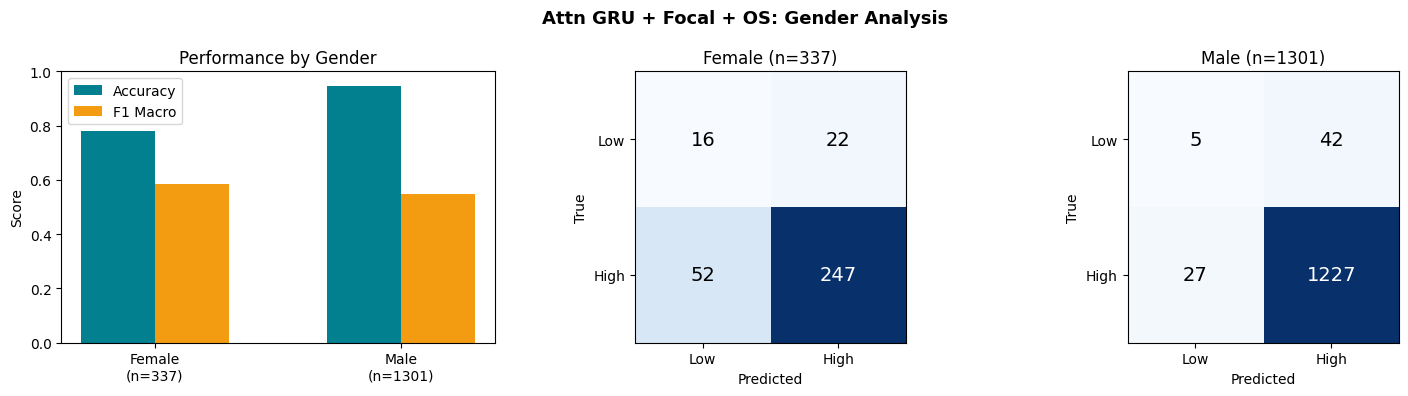

In [ ]:
# --- Gender comparison visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart: Accuracy and F1 by gender
gender_results = {}
for gender in ["Female", "Male"]:
    mask = test_gender_cached[:len(all_preds)] == gender
    if mask.sum() > 0:
        gender_results[gender] = {
            "accuracy": accuracy_score(all_labels[mask], all_preds[mask]),
            "f1_macro": f1_score(all_labels[mask], all_preds[mask], average="macro", zero_division=0),
            "n": mask.sum()
        }

genders = list(gender_results.keys())
accs = [gender_results[g]["accuracy"] for g in genders]
f1s = [gender_results[g]["f1_macro"] for g in genders]

x = np.arange(len(genders))
axes[0].bar(x - 0.15, accs, 0.3, label="Accuracy", color="#028090")
axes[0].bar(x + 0.15, f1s, 0.3, label="F1 Macro", color="#F39C12")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{g}\n(n={gender_results[g]['n']})" for g in genders])
axes[0].set_ylabel("Score")
axes[0].set_title("Performance by Gender")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Confusion matrices by gender
for idx, gender in enumerate(genders):
    mask = test_gender_cached[:len(all_preds)] == gender
    cm = confusion_matrix(all_labels[mask], all_preds[mask])
    ax = axes[idx + 1]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{gender} (n={mask.sum()})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Low", "High"]); ax.set_yticklabels(["Low", "High"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.suptitle("Attn GRU + Focal + OS: Gender Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gender_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

 ## 8. Leave-One-User-Out Cross-Validation (LOUO)

 Train on N-1 users, test on 1 unseen user.
 This stress-tests whether the model generalizes to unseen individuals.

In [ ]:
print("=" * 70)
print("LEAVE-ONE-USER-OUT CROSS-VALIDATION")
print("=" * 70)

# Combine all data for LOUO
all_app_seq = np.concatenate([train_app, val_app, test_app], axis=0)
all_geo_seq = np.concatenate([train_geo, val_geo, test_geo], axis=0)
all_lbl_full = np.concatenate([train_lbl, val_lbl, test_lbl], axis=0)

# Get user IDs from clip IDs (first 6 chars)
all_labels_df = pd.concat([train_labels_df, val_labels_df, test_labels_df], ignore_index=True)

# Match cached features count
n_total_cached = len(all_app_seq)
n_total_csv = len(all_labels_df)
print(f"Total cached: {n_total_cached}, Total CSV: {n_total_csv}")

# Extract user IDs
if n_total_cached == n_total_csv:
    all_clip_ids = all_labels_df["ClipID"].values
else:
    # Reconstruct valid indices
    valid = []
    for _, row in all_labels_df.iterrows():
        clip_id = row["ClipID"].replace(".avi", "")
        subject_id = clip_id[:6]
        split = "Train" if _ < len(train_labels_df) else ("Validation" if _ < len(train_labels_df) + len(val_labels_df) else "Test")
        vpath = os.path.join(DAISEE_ROOT, "DataSet", split, subject_id, clip_id, clip_id + ".avi")
        valid.append(os.path.exists(vpath))
    all_clip_ids = all_labels_df["ClipID"].values[np.array(valid)][:n_total_cached]

all_user_ids = np.array([c.replace(".avi", "")[:6] for c in all_clip_ids])
unique_users = np.unique(all_user_ids)
print(f"Unique users: {len(unique_users)}")

# Binary labels
all_eng_binary = (all_lbl_full[:, TARGET_COL] >= 2).astype(np.int64)

# Run LOUO — sample a subset of users for efficiency
np.random.seed(42)
sample_users = np.random.choice(unique_users, size=min(20, len(unique_users)), replace=False)
print(f"Running LOUO on {len(sample_users)} sampled users...")

louo_results = []

for i, test_user in enumerate(sample_users):
    mask_test = all_user_ids == test_user
    mask_train = ~mask_test
    
    if mask_test.sum() == 0 or mask_train.sum() == 0:
        continue
    
    # Create datasets
    tr_ds = SeqDataset(all_app_seq[mask_train], all_geo_seq[mask_train],
                       all_lbl_full[mask_train], TARGET_COL, binary=True)
    te_ds = SeqDataset(all_app_seq[mask_test], all_geo_seq[mask_test],
                       all_lbl_full[mask_test], TARGET_COL, binary=True)
    
    tr_loader = make_loader(tr_ds, oversample=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Train model (fewer epochs for speed)
    model = AttentionGRU(num_classes=2)
    cw_louo = get_class_weights(tr_ds)
    cr = FocalLoss(alpha=cw_louo, gamma=2.0)
    
    # Suppress per-epoch output
    model.to(device)
    if hasattr(cr, 'alpha') and cr.alpha is not None:
        cr.alpha = cr.alpha.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    
    for epoch in range(15):  # fewer epochs for speed
        model.train()
        for a, g, l in tr_loader:
            a, g, l = a.to(device), g.to(device), l.to(device)
            optimizer.zero_grad()
            cr(model(a, g), l).backward()
            optimizer.step()
    
    # Evaluate
    r = evaluate_model(model, te_loader, binary=True)
    louo_results.append({
        "user": test_user,
        "n_clips": mask_test.sum(),
        "accuracy": r["accuracy"],
        "f1_macro": r["f1_macro"]
    })
    
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(sample_users)} users done...")

louo_df = pd.DataFrame(louo_results)
print(f"\n{'='*60}")
print("LOUO RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {louo_df['accuracy'].mean():.4f} ± {louo_df['accuracy'].std():.4f}")
print(f"Mean F1 Macro: {louo_df['f1_macro'].mean():.4f} ± {louo_df['f1_macro'].std():.4f}")
print(f"\nPer-user results:")
print(louo_df.to_string(index=False))

LEAVE-ONE-USER-OUT CROSS-VALIDATION
Total cached: 7919, Total CSV: 8571
Unique users: 101
Running LOUO on 20 sampled users...
  5/20 users done...
  10/20 users done...
  15/20 users done...
  20/20 users done...

LOUO RESULTS
Mean Accuracy: 0.4717 ± 0.3027
Mean F1 Macro: 0.3329 ± 0.1838

Per-user results:
  user  n_clips  accuracy  f1_macro
510035       84  0.333333  0.301248
334463      108  0.046296  0.044248
410025      112  0.285714  0.284802
410026       85  0.505882  0.459091
310074      107  0.018692  0.018349
310068       19  0.631579  0.614493
205601       88  0.715909  0.453144
310073       46  0.108696  0.098039
110013        8  0.500000  0.466667
110001      114  0.157895  0.136364
200048       31  0.516129  0.340426
210059      124  0.822581  0.451327
928901       84  0.595238  0.442188
226051       95  0.884211  0.469274
500039      108  0.787037  0.513228
110006       79  0.924051  0.480263
556463       95  0.157895  0.136364
500043       13  0.076923  0.071429
110015  

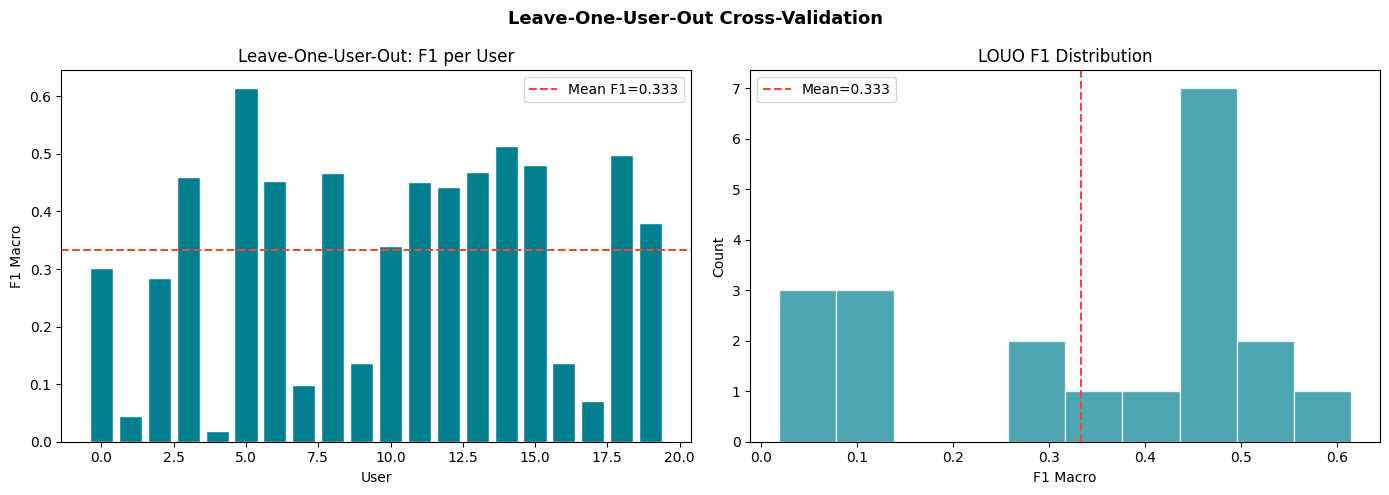

In [ ]:
# --- LOUO Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Per-user performance
ax1.bar(range(len(louo_df)), louo_df["f1_macro"], color="#028090", edgecolor="white")
ax1.axhline(y=louo_df["f1_macro"].mean(), color="#E74C3C", linestyle="--",
            label=f"Mean F1={louo_df['f1_macro'].mean():.3f}")
ax1.set_xlabel("User")
ax1.set_ylabel("F1 Macro")
ax1.set_title("Leave-One-User-Out: F1 per User")
ax1.legend()

# Distribution
ax2.hist(louo_df["f1_macro"], bins=10, color="#028090", edgecolor="white", alpha=0.7)
ax2.axvline(x=louo_df["f1_macro"].mean(), color="#E74C3C", linestyle="--",
            label=f"Mean={louo_df['f1_macro'].mean():.3f}")
ax2.set_xlabel("F1 Macro")
ax2.set_ylabel("Count")
ax2.set_title("LOUO F1 Distribution")
ax2.legend()

plt.suptitle("Leave-One-User-Out Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("louo_results.png", dpi=150, bbox_inches="tight")
plt.show()